In [1]:
import re
import emoji
import contractions
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# To display all rows
pd.set_option('display.max_rows', None)

# To display all columns
pd.set_option('display.max_columns', None)

# To prevent column content truncation
pd.set_option('display.max_colwidth', None)

### Load dataset

In [3]:
file_path = "laptops_dataset_final_600.xlsx"
laptops_df = pd.read_excel(file_path)

### Descriptive Analysis

In [4]:
laptops_df.head()

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork ðŸ¥ºâ¤ï¸"
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Fabulous!,Battery lasted longer than my first relationship (2 days).\nListening to Arijit singh songs on full volume since then still isn't getting over. Has more warmth than her. unlike her there's two way communication here as touchpad is very responsive. fingerprint lock is nice as it only opens up to me. 5 stars for this -1 for her
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Fabulous!,Such a great deal.. very happy with the performance and battery life..Origional product..ðŸ¥°â¤ï¸\nThank you Flipkart..!!!
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,4,Delightful,"Awesome build quality and very good display, battery and camera. Still new to macOS"
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Awesome,"When i ordered and came to know about seller review,i was scared that in what condition i will get macbook. but i was wrong.\n\nThis is my first macbook and i am fully satisfied with the product with original packaging of apple and got genuine product.\n\nIt's very thin and light and looks very premium.\n\nAs A software developer, i installed intellij idea ide and guess what.\nIt's magic,it is opening just in a click and within 5 seconds.\nGreat performance, no heating issue, sound quality awesome an...\nREAD MORE"


In [5]:
laptops_df.tail()

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
24108,MSI Modern 14 Intel Core i5 13th Gen 1335U - (8 GB/512 GB SSD/...,4.3,156,24,5,Perfect product!,"MSI Laptop is high performance and the best. configuration is better than HP,Dell .\nValue for money laptop\n\nCon\nBattery backup is up to 5 hours"
24109,MSI Modern 14 Intel Core i5 13th Gen 1335U - (8 GB/512 GB SSD/...,4.3,156,24,5,Perfect product!,Excellent performance best laptop.
24110,MSI Modern 14 Intel Core i5 13th Gen 1335U - (8 GB/512 GB SSD/...,4.3,156,24,4,"Good product, Lacks features.","Decent battery life. Exceptional build quality. Lacks features like USB-C charger, privacy shutter for camera, fingerprint reader, MS Office."
24111,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 Octa Core 8845HS...,4.4,7,2,3,Nice,The product does not support facial recognition as it does not have an IR sensor
24112,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 Octa Core 8845HS...,4.4,7,2,4,Very Good,DISPLAY IS A LET DOWN. But the lenovo Pen works like a CHARM. I haven't yet tested it with powerful apps but i believe AMD Ryzen 7 can handle it. This is the CHEAPEST LAPTOP with AMD 8845H I guess


In [6]:
laptops_df.sample(10)

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
4326,Lenovo Intel Core i7 12th Gen 1255U - (16 GB/512 GB SSD/Window...,4.1,1281,112,3,Does the job,Good product lenovo
5822,"ASUS Vivobook 16X for Creator, Intel Core i5 12th Gen 12500H -...",4.2,477,45,4,Really Nice,Asus vivobook 16x creator laptop is so good but when update and restart the laptop the screen has get yellow screen on all edge and corner of the screen
3398,Acer Aspire 7 Intel Core i5 13th Gen 13420H - (16 GB/512 GB SS...,4.3,1298,98,5,Great product,Every thing is good. But we are not going to get the charger of acer company. So dont be panic during delivery time.. I got the charger of Liteon 120 w
22910,ASUS Intel Core i3 11th Gen 1115G4 - (8 GB/512 GB SSD/Windows ...,4.3,3552,263,5,Awesome,Good
1906,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Fabulous!,Its a light weight powerful machine which is smooth and has zero lags.\nThe keypad quality is good.\nMidnight black color looks very elegant.
9217,Lenovo IdeaPad 3 Intel Core i3 12th Gen 1215U - (8 GB/512 GB S...,4.3,1502,85,5,Super!,Ok good
2653,HP Intel Core i5 12th Gen 1235U - (16 GB/512 GB SSD/Windows 11...,4.2,5248,272,5,Mind-blowing purchase,Good product.
1390,Primebook Wifi MediaTek MT8183 - (4 GB/64 GB EMMC Storage/Prim...,4.2,2885,725,5,Classy product,Good product! Its running smoothly and performing wellðŸ–¤
21173,HP 255 G9 AMD Athlon Dual Core AMD Athlon Silver-3050U - (4 GB...,3.9,1694,128,5,Super!,"Nice laptop under cheap price ,,\nSomething nice"
9412,HP Pavilion 15 (2024) AMD Ryzen 5 Hexa Core 7530U - (8 GB/512 ...,4.3,1006,102,5,Worth every penny,Over-all its a good laptop


In [7]:
laptops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24113 entries, 0 to 24112
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    24113 non-null  object 
 1   overall_rating  24113 non-null  float64
 2   no_ratings      24113 non-null  int64  
 3   no_reviews      24113 non-null  int64  
 4   rating          24113 non-null  int64  
 5   title           24113 non-null  object 
 6   review          24113 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


In [8]:
laptops_df.describe()

,overall_rating,no_ratings,no_reviews,rating
count,24113.000000,24113.000000,24113.000000,24113.000000
mean,4.186273,2712.264712,224.708290,4.214573
std,0.228392,3155.612617,251.353414,1.184845
min,3.300000,1.000000,1.000000,1.000000
25%,4.100000,660.000000,62.000000,4.000000
50%,4.200000,1569.000000,133.000000,5.000000
75%,4.300000,3475.000000,310.000000,5.000000
max,5.000000,15729.000000,2171.000000,5.000000


In [9]:
laptops_df.isnull().sum()

product_name      0
overall_rating    0
no_ratings        0
no_reviews        0
rating            0
title             0
review            0
dtype: int64

### Map ratings to sentiment

In [10]:
def map_sentiment(r):
    if r in [1, 2]:
        return "negative"
    elif r == 3:
        return "neutral"
    elif r in [4, 5]:
        return "positive"
    return None

laptops_df['sentiment'] = laptops_df['rating'].apply(map_sentiment)

In [11]:
laptops_df.head()

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review,sentiment
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork ðŸ¥ºâ¤ï¸",positive
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Fabulous!,Battery lasted longer than my first relationship (2 days).\nListening to Arijit singh songs on full volume since then still isn't getting over. Has more warmth than her. unlike her there's two way communication here as touchpad is very responsive. fingerprint lock is nice as it only opens up to me. 5 stars for this -1 for her,positive
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Fabulous!,Such a great deal.. very happy with the performance and battery life..Origional product..ðŸ¥°â¤ï¸\nThank you Flipkart..!!!,positive
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,4,Delightful,"Awesome build quality and very good display, battery and camera. Still new to macOS",positive
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,15210,900,5,Awesome,"When i ordered and came to know about seller review,i was scared that in what condition i will get macbook. but i was wrong.\n\nThis is my first macbook and i am fully satisfied with the product with original packaging of apple and got genuine product.\n\nIt's very thin and light and looks very premium.\n\nAs A software developer, i installed intellij idea ide and guess what.\nIt's magic,it is opening just in a click and within 5 seconds.\nGreat performance, no heating issue, sound quality awesome an...\nREAD MORE",positive


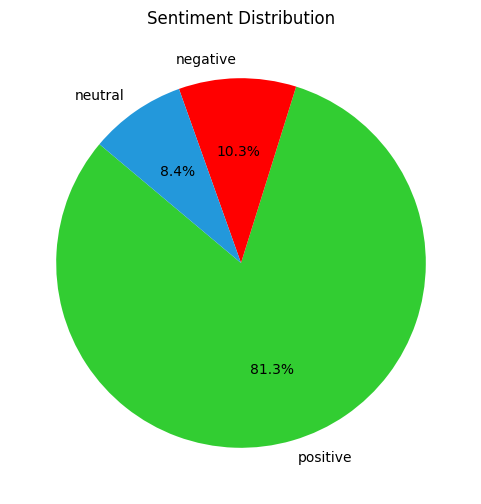

In [12]:
laptops_df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',   # show percentages
    startangle=140,      # rotate chart
    colors=['#32CD32','red','#2398DB'],
    figsize=(6, 6)       # chart size
)

plt.ylabel('')   # remove y-axis label
plt.title("Sentiment Distribution")
plt.show()

### Pre Processing the Dataset

In [13]:
# Comprehensive text cleaning function
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()  # lowercase
    
    text = contractions.fix(text)  # expand contractions
    
    text = emoji.demojize(text, delimiters=(" ", " "))  # convert emojis to words
    
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)  # remove urls
    
    text = re.sub(r"\S+@\S+", " emailaddress ", text)  # replace emails
    
    text = re.sub(r"@\w+", " user ", text)  # replace mentions
    
    text = re.sub(r"#(\w+)", r"\1", text)  # remove hashtags
    
    text = re.sub(r"<.*?>", " ", text)  # remove html tags
    
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # remove numbers and punctuation
    
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    
    return text

In [14]:
# Apply cleaning on reviews (keep original too)
laptops_df['clean_review'] = laptops_df['review'].apply(clean_text)

In [15]:
# Drop rows without valid sentiment
laptops_df = laptops_df.dropna(subset=['sentiment'])

In [16]:
laptops_df[['review', 'clean_review', 'rating', 'sentiment']].head()

,review,clean_review,rating,sentiment
0,"Loved it, it's my first MacBook that I earned from my hardwork ðŸ¥ºâ¤ï¸",loved it it is my first macbook that i earned from my hardwork,5,positive
1,Battery lasted longer than my first relationship (2 days).\nListening to Arijit singh songs on full volume since then still isn't getting over. Has more warmth than her. unlike her there's two way communication here as touchpad is very responsive. fingerprint lock is nice as it only opens up to me. 5 stars for this -1 for her,battery lasted longer than my first relationship days listening to arijit singh songs on full volume since then still is not getting over has more warmth than her unlike her there is two way communication here as touchpad is very responsive fingerprint lock is nice as it only opens up to me stars for this for her,5,positive
2,Such a great deal.. very happy with the performance and battery life..Origional product..ðŸ¥°â¤ï¸\nThank you Flipkart..!!!,such a great deal very happy with the performance and battery life origional product thank you flipkart,5,positive
3,"Awesome build quality and very good display, battery and camera. Still new to macOS",awesome build quality and very good display battery and camera still new to macos,4,positive
4,"When i ordered and came to know about seller review,i was scared that in what condition i will get macbook. but i was wrong.\n\nThis is my first macbook and i am fully satisfied with the product with original packaging of apple and got genuine product.\n\nIt's very thin and light and looks very premium.\n\nAs A software developer, i installed intellij idea ide and guess what.\nIt's magic,it is opening just in a click and within 5 seconds.\nGreat performance, no heating issue, sound quality awesome an...\nREAD MORE",when i ordered and came to know about seller review i was scared that in what condition i will get macbook but i was wrong this is my first macbook and i am fully satisfied with the product with original packaging of apple and got genuine product it is very thin and light and looks very premium as a software developer i installed intellij idea ide and guess what it is magic it is opening just in a click and within seconds great performance no heating issue sound quality awesome an read more,5,positive


In [17]:
laptops_df['sentiment'].value_counts()

sentiment
positive    19601
negative     2477
neutral      2035
Name: count, dtype: int64

## Objective 1

#### To compare advanced sentiment analysis model with traditional models for accurately classifying e-commerce customer reviews.

### Importing Necessary Libraries

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

### Splitting the dataset

In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    laptops_df['clean_review'], 
    laptops_df['sentiment'], 
    test_size=0.2, 
    stratify=laptops_df['sentiment'], 
    random_state=42
)

In [20]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Traditional models

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

In [22]:
# Train & evaluate models
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    print(f"\n{name} Results:")
    print(classification_report(y_test, preds))


Logistic Regression Results:
              precision    recall  f1-score   support

    negative       0.84      0.74      0.79       495
     neutral       0.73      0.22      0.34       407
    positive       0.91      0.99      0.95      3921

    accuracy                           0.90      4823
   macro avg       0.83      0.65      0.69      4823
weighted avg       0.89      0.90      0.88      4823


Naive Bayes Results:
              precision    recall  f1-score   support

    negative       0.88      0.38      0.53       495
     neutral       1.00      0.06      0.11       407
    positive       0.85      1.00      0.92      3921

    accuracy                           0.86      4823
   macro avg       0.91      0.48      0.52      4823
weighted avg       0.87      0.86      0.81      4823


SVM Results:
              precision    recall  f1-score   support

    negative       0.84      0.79      0.82       495
     neutral       0.74      0.36      0.48       407
    posit

### BERT Model

### Importing Necessary Models for BERT

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm

C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
# Check if CUDA is available and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [25]:
# Custom Dataset class
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [27]:
df = laptops_df

In [35]:
# Encode labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
laptops_df["label"] = laptops_df["sentiment"].map(label_map)

# Split data into train and test sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['review'].tolist(), 
    df['label'].tolist(), 
    test_size=0.2, 
    random_state=42
)

# Initialize tokenizer and parameters
PRE_TRAINED_MODEL_NAME = 'bert-base-uncased'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3

tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

In [36]:
# Create DataLoaders
train_dataset = ReviewDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [37]:
# Load BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL_NAME, num_labels=3)
model = model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
# Training function
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in tqdm(data_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    return total_loss / len(data_loader)

In [39]:
# Evaluation function
def eval_model(model, data_loader, device):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels

In [40]:
# Training loop
for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_loss = train_epoch(model, train_loader, optimizer, device)
    print(f'Train loss: {train_loss}')
    
    preds, labels = eval_model(model, val_loader, device)
    acc = accuracy_score(labels, preds)
    print(f'Validation Accuracy: {acc}')

Epoch 1/3


100%|██████████████████████████████████████████████████████████████████████████████| 1206/1206 [04:17<00:00,  4.68it/s]


Train loss: 0.31087669454959793
Validation Accuracy: 0.9263943603566245
Epoch 2/3


100%|██████████████████████████████████████████████████████████████████████████████| 1206/1206 [04:42<00:00,  4.27it/s]


Train loss: 0.2091671437940948
Validation Accuracy: 0.9367613518556914
Epoch 3/3


100%|██████████████████████████████████████████████████████████████████████████████| 1206/1206 [04:07<00:00,  4.87it/s]


Train loss: 0.15097493942978346
Validation Accuracy: 0.9481650425046652


Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91       507
     neutral       0.75      0.59      0.66       376
    positive       0.97      0.99      0.98      3940

    accuracy                           0.95      4823
   macro avg       0.88      0.83      0.85      4823
weighted avg       0.94      0.95      0.95      4823



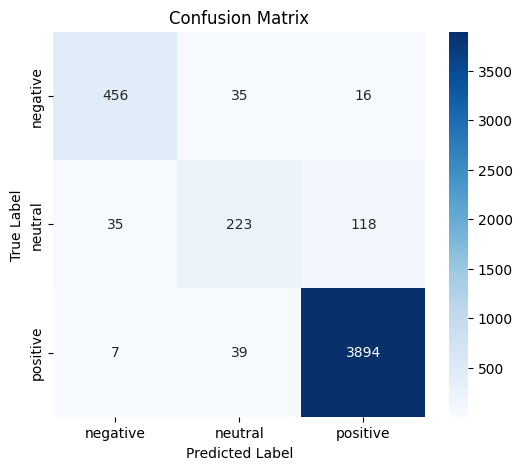

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# preds and labels are from your eval_model function output for the validation set

# 1. Print classification report
print("Classification Report:")
print(classification_report(labels, preds, target_names=["negative", "neutral", "positive"]))

# 2. Generate confusion matrix
cm = confusion_matrix(labels, preds)

# 3. Visualize confusion matrix with heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["negative", "neutral", "positive"], 
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### As we saw the data was not accurately distributed across all the classes of sentiments. Hence we will balance the dataset and test the dataset to see if there is any differenece between then balanced and non balanced datatset.

## Objective 2:

### Comparison of Models Performance on unbalanced and balanced dataset

In [49]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

In [50]:
# Train-test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    laptops_df["review"].astype(str).fillna(""), 
    laptops_df["sentiment"], 
    test_size=0.2, 
    stratify=laptops_df["sentiment"], 
    random_state=42
)

In [51]:
# Vectorize
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Oversample training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_vec, y_train)

print("Before balancing:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After balancing:", dict(zip(*np.unique(y_train_bal, return_counts=True))))

Before balancing: {'negative': np.int64(1982), 'neutral': np.int64(1628), 'positive': np.int64(15680)}
After balancing: {'negative': np.int64(15680), 'neutral': np.int64(15680), 'positive': np.int64(15680)}


In [52]:
# ---- Train models on balanced data ----
# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_vec)
print("\nLogistic Regression (Balanced):\n", classification_report(y_test, y_pred_lr))

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_bal, y_train_bal)
y_pred_nb = nb.predict(X_test_vec)
print("\nNaive Bayes (Balanced):\n", classification_report(y_test, y_pred_nb))

# SVM
svm = LinearSVC()
svm.fit(X_train_bal, y_train_bal)
y_pred_svm = svm.predict(X_test_vec)
print("\nSVM (Balanced):\n", classification_report(y_test, y_pred_svm))


Logistic Regression (Balanced):
               precision    recall  f1-score   support

    negative       0.83      0.88      0.85       495
     neutral       0.47      0.69      0.56       407
    positive       0.97      0.92      0.94      3921

    accuracy                           0.90      4823
   macro avg       0.76      0.83      0.79      4823
weighted avg       0.92      0.90      0.90      4823


Naive Bayes (Balanced):
               precision    recall  f1-score   support

    negative       0.73      0.84      0.78       495
     neutral       0.35      0.68      0.46       407
    positive       0.97      0.86      0.91      3921

    accuracy                           0.84      4823
   macro avg       0.68      0.79      0.72      4823
weighted avg       0.90      0.84      0.86      4823


SVM (Balanced):
               precision    recall  f1-score   support

    negative       0.83      0.89      0.86       495
     neutral       0.55      0.71      0.62       4

### BERT analysis for weighted dataset

In [53]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.nn as nn

# Compute class weights for BERT
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class Weights for BERT:", class_weights)

# Define weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

Class Weights for BERT: tensor([3.2442, 3.9496, 0.4101], device='cuda:0')


In [54]:
# Encode labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
laptops_df["label"] = laptops_df["sentiment"].map(label_map)

# Train-test split (same as before, but raw review for BERT)
X_train, X_test, y_train, y_test = train_test_split(
    laptops_df["review"], 
    laptops_df["label"], 
    test_size=0.2, 
    stratify=laptops_df["label"], 
    random_state=42
)

In [55]:
# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [56]:
# Custom Dataset
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [57]:
# Create datasets
train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset = ReviewDataset(X_test, y_test, tokenizer)

In [58]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [59]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
model = model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [60]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

In [61]:
# Training loop
epochs = 2
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = criterion(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/2, Loss: 0.6139
Epoch 2/2, Loss: 0.4244


In [62]:
# Evaluation
model.eval()
preds, true_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1).cpu().numpy()

        preds.extend(predictions)
        true_labels.extend(labels.cpu().numpy())

print("\nBERT Classification Report:")
print(classification_report(true_labels, preds, target_names=label_map.keys()))


BERT Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.94      0.89       495
     neutral       0.56      0.58      0.57       407
    positive       0.97      0.95      0.96      3921

    accuracy                           0.92      4823
   macro avg       0.79      0.82      0.81      4823
weighted avg       0.92      0.92      0.92      4823



## Objective 3

### To implement aspect-based sentiment analysis for extracting sentiments related to specific product/service features.

In [63]:
import spacy
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Check if CUDA is available and set device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [64]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)  # Move model to GPU if available
model.eval()

C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [65]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}

def extract_aspects(text):
    doc = nlp(text)
    aspects = set()
    for chunk in doc.noun_chunks:
        root = chunk.root
        if root.pos_ in {"NOUN", "PROPN"} and not root.is_stop:
            aspects.add(root.text.lower())
    return list(aspects)

def predict_aspect_sentiment(review, aspect):
    encoded = tokenizer.encode_plus(
        review,
        aspect,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256,
    )
    # Move tensors to the same device as the model
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return label_map[pred]

def aspect_based_sentiment(review):
    aspects = extract_aspects(review)
    results = {}
    for aspect in aspects:
        sentiment = predict_aspect_sentiment(review, aspect)
        results[aspect] = sentiment
    return results

In [67]:
file_path = "laptops_dataset_final_600.xlsx"
laptops_df = pd.read_excel(file_path)

# Apply ABSA with CUDA acceleration
df["aspect_sentiments"] = df["review"].apply(aspect_based_sentiment)

print(df[["review", "aspect_sentiments"]])

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      review  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Loved it, it's my fir

In [68]:
from collections import Counter
from sentence_transformers import SentenceTransformer, util

In [69]:
# 1. Extract all aspects listed in the dictionaries for each review
all_aspects = []
for aspects_dict in df['aspect_sentiments']:
    if isinstance(aspects_dict, dict):
        all_aspects.extend(aspects_dict.keys())

In [70]:
# 2. Count the frequency of each aspect
aspect_counts = Counter(all_aspects)

# Convert to DataFrame for easy plotting
aspect_counts_df = pd.DataFrame.from_dict(aspect_counts, orient='index', columns=['count'])
aspect_counts_df = aspect_counts_df.sort_values(by='count', ascending=False)

In [71]:
aspect_counts_df.head()

,count
product,45
performance,42
laptop,38
battery,17
quality,17


In [72]:
model = SentenceTransformer('all-MiniLM-L6-v2')

# Seed keywords representing laptop-related concepts
laptop_seeds = ["laptop", "battery", "screen", "performance", "camera",
                "design", "price", "processor", "ram", "graphics", "display",
                "keyboard", "touchpad", "storage", "port", "connectivity", "speaker"]

# Encode seed keywords and aspects
seed_emb = model.encode(laptop_seeds, convert_to_tensor=True)
aspect_list = list(aspect_counts.keys())
aspect_emb = model.encode(aspect_list, convert_to_tensor=True)

# Compute cosine similarity between aspects and seeds
cos_scores = util.pytorch_cos_sim(aspect_emb, seed_emb)

# Threshold to filter aspects relevant to laptop domain (adjust as needed)
threshold = 0.5

# Select aspects with similarity above threshold to any seed keyword
relevant_aspects = []
for idx, aspect in enumerate(aspect_list):
    max_sim = cos_scores[idx].max().item()
    if max_sim >= threshold:
        relevant_aspects.append((aspect, aspect_counts[aspect]))

<Figure size 1000x500 with 0 Axes>

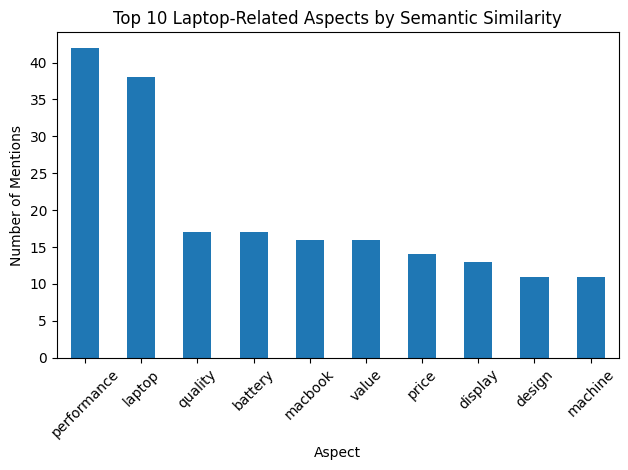

In [73]:
# Convert to DataFrame for analysis/plotting
relevant_df = pd.DataFrame(relevant_aspects, columns=['aspect', 'count'])
relevant_df = relevant_df.sort_values(by='count', ascending=False)

top_10 = relevant_df.head(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind='bar', x='aspect', y='count', legend=False, rot=45)
plt.title('Top 10 Laptop-Related Aspects by Semantic Similarity')
plt.xlabel('Aspect')
plt.ylabel('Number of Mentions')
plt.tight_layout()
plt.show()

In [79]:
relevant_df.head()

,aspect,count
4,performance,42
10,laptop,38
7,quality,17
1,battery,17
0,macbook,16


### Sentiment Distribution of Aspects of a particular product

In [74]:
from collections import defaultdict

product_name = "Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)..."  # specify product

# Filter reviews for the product
product_reviews = df[df['product_name'] == product_name]
print(product_reviews.head())
# Aggregate sentiment counts per aspect
sentiment_counts = defaultdict(lambda: {'positive':0, 'neutral':0, 'negative':0})

for aspect_dict in product_reviews['aspect_sentiments']:
    if isinstance(aspect_dict, dict):
        for aspect, sentiment in aspect_dict.items():
            if sentiment in sentiment_counts[aspect]:
                sentiment_counts[aspect][sentiment] += 1

                                                        product_name  \
0  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
1  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
2  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
3  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
4  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   

   overall_rating  no_ratings  no_reviews  rating             title  \
0             4.7       15210         900       5  Perfect product!   
1             4.7       15210         900       5         Fabulous!   
2             4.7       15210         900       5         Fabulous!   
3             4.7       15210         900       4        Delightful   
4             4.7       15210         900       5           Awesome   

                                                                                                                                            

In [75]:
# Convert to DataFrame
df_c = pd.DataFrame.from_dict(sentiment_counts, orient='index')
df_c.fillna(0, inplace=True)

In [76]:
df_c.head()

,positive,neutral,negative
macbook,13,3,0
hardwork,1,0,0
songs,1,0,0
battery,9,0,0
touchpad,1,0,0


In [82]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 253 entries, macbook to thing
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   positive  253 non-null    int64
 1   neutral   253 non-null    int64
 2   negative  253 non-null    int64
 3   total     253 non-null    int64
dtypes: int64(4)
memory usage: 9.9+ KB


In [83]:
# Select top 10 aspects by total mentions
df_c['total'] = df_c.sum(axis=1)
top_10 = df_c.nlargest(10, 'total')
top_10 = top_10.drop(columns=['total'])

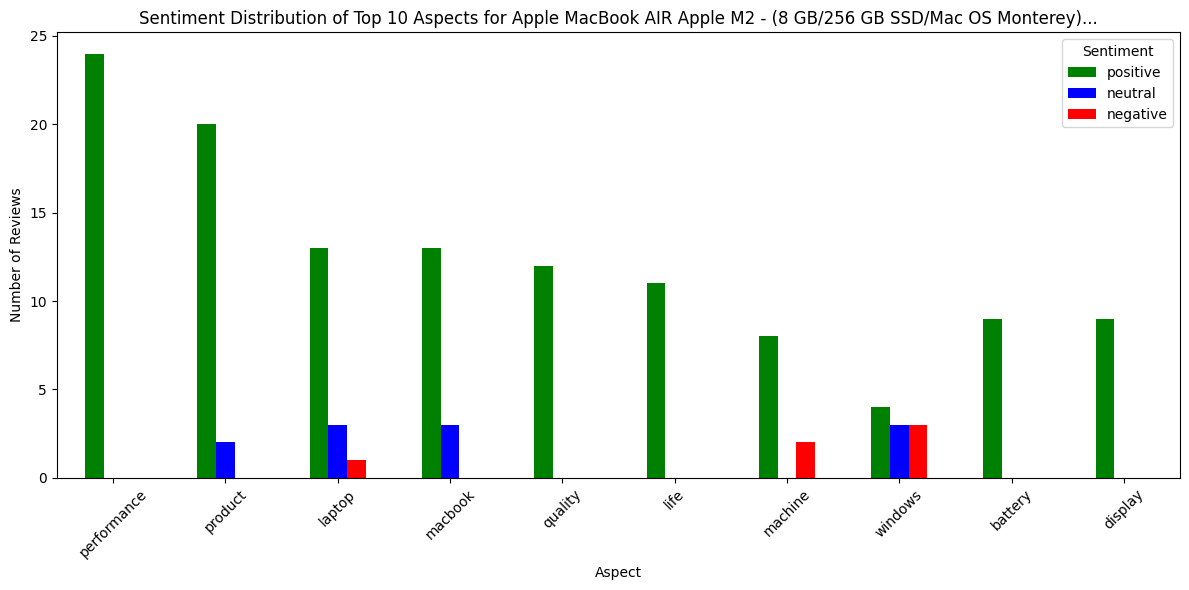

In [84]:
# Plot grouped bar chart
ax = top_10.plot(kind='bar', figsize=(12,6), color=['green', 'blue', 'red'])
plt.title(f'Sentiment Distribution of Top 10 Aspects for {product_name}')
plt.xlabel('Aspect')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Objective 4:

### To analyze the correlation between numerical ratings and textual sentiment expressed in reviews, identifying any inconsistencies or patterns.

In [85]:
import pandas as pd
from textblob import TextBlob
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [86]:
# Load your dataset
df = pd.read_csv('laptops_dataset_final_600.csv')  # replace with your dataset filename/path

In [87]:
# Preview data
print(df.head())

                                                        product_name  \
0  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
1  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
2  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
3  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   
4  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...   

   overall_rating no_ratings no_reviews  rating             title  \
0             4.7     15,210        900       5  Perfect product!   
1             4.7     15,210        900       5         Fabulous!   
2             4.7     15,210        900       5         Fabulous!   
3             4.7     15,210        900       4        Delightful   
4             4.7     15,210        900       5           Awesome   

                                                                                                                                                        

In [88]:
# Combine title and review for fuller text analysis
df['full_review'] = df['title'].fillna('') + ' ' + df['review'].fillna('')

In [89]:
# Calculate sentiment polarity from combined text
def get_sentiment(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0

df['sentiment_score'] = df['full_review'].apply(get_sentiment)

# Map sentiment polarity score to categorical label
def polarity_to_label(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(polarity_to_label)

# Map numeric ratings to sentiment labels for comparison
def rating_to_label(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

In [90]:
df['rating_label'] = df['rating'].apply(rating_to_label)

In [91]:
# Calculate Pearson correlation between numeric rating and sentiment polarity
corr, p_value = pearsonr(df['rating'], df['sentiment_score'])
print(f'Pearson correlation: {corr:.3f}, p-value: {p_value:.3e}')

Pearson correlation: 0.649, p-value: 0.000e+00


In [92]:
# Calculate inconsistency rate where rating label and sentiment label differ
df['inconsistency'] = df['rating_label'] != df['sentiment_label']
inconsistency_rate = df['inconsistency'].mean()
print(f'Inconsistency rate between rating label and sentiment label: {inconsistency_rate:.2%}')

Inconsistency rate between rating label and sentiment label: 13.60%


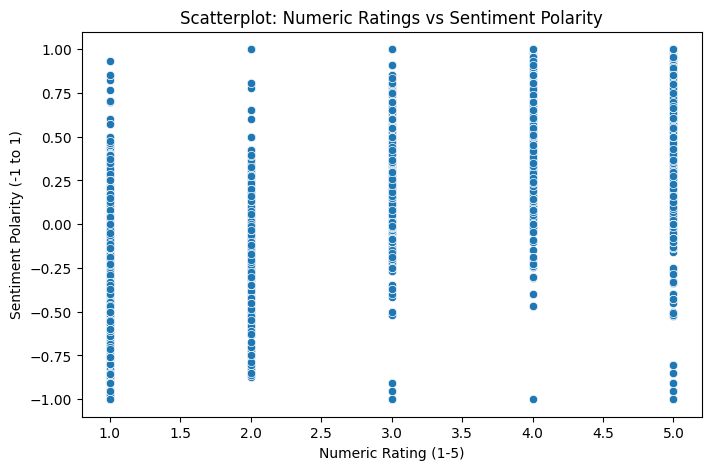

In [93]:
# Visualize correlation
plt.figure(figsize=(8,5))
sns.scatterplot(x='rating', y='sentiment_score', data=df)
plt.title('Scatterplot: Numeric Ratings vs Sentiment Polarity')
plt.xlabel('Numeric Rating (1-5)')
plt.ylabel('Sentiment Polarity (-1 to 1)')
plt.show()

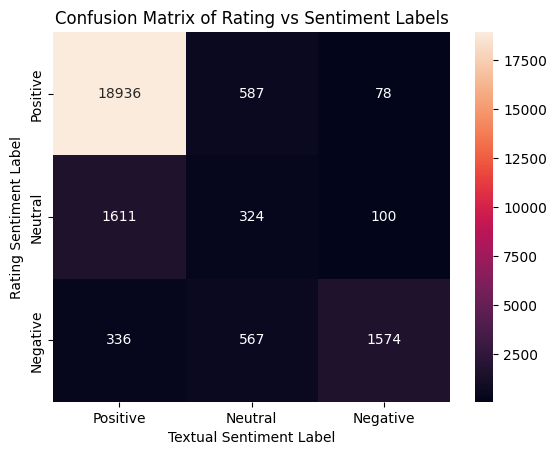

In [94]:
# Confusion matrix displaying agreement between rating-based and text-based sentiment
cm = confusion_matrix(df['rating_label'], df['sentiment_label'], labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Positive','Neutral','Negative'], yticklabels=['Positive','Neutral','Negative'])
plt.xlabel('Textual Sentiment Label')
plt.ylabel('Rating Sentiment Label')
plt.title('Confusion Matrix of Rating vs Sentiment Labels')
plt.show()

In [95]:
# Classification report for detailed metrics
print(classification_report(df['rating_label'], df['sentiment_label']))

              precision    recall  f1-score   support

    negative       0.90      0.64      0.74      2477
     neutral       0.22      0.16      0.18      2035
    positive       0.91      0.97      0.94     19601

    accuracy                           0.86     24113
   macro avg       0.67      0.59      0.62     24113
weighted avg       0.85      0.86      0.85     24113

